In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [2]:
df_clusters = pd.read_pickle("documentos_2004_2024_preprocesados.pkl")

print("Shape:", df_clusters.shape)
print("Tipo de resuelve_tokens:", type(df_clusters["resuelve_tokens"].iloc[0]))
print(df_clusters["resuelve_tokens"].head(3).to_list())

Shape: (23518, 8)
Tipo de resuelve_tokens: <class 'list'>
[['modificar', 'prestacion', 'servicios', 'salud', 'sistema', 'seguridad', 'social'], ['aprobar', 'presupuesto', 'fondos', 'generales', 'vigencia', 'fiscal'], ['aprobar', 'presupuesto', 'fondos', 'seguridad', 'social', 'vigencia', 'fiscal']]


In [3]:
df_clusters["resuelve_doc"] = df_clusters["resuelve_tokens"].apply(lambda toks: " ".join(toks))

print(df_clusters["resuelve_doc"].head(3).to_list())

['modificar prestacion servicios salud sistema seguridad social', 'aprobar presupuesto fondos generales vigencia fiscal', 'aprobar presupuesto fondos seguridad social vigencia fiscal']


In [4]:
docs = df_clusters["resuelve_doc"].fillna("").tolist()

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2746.83it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 368/368 [05:48<00:00,  1.06it/s]


Shape embeddings: (23518, 384)


In [5]:
# Guardado opcional para no recalcular
np.save("embeddings_resuelve.npy", embeddings)

In [6]:
resultados_kmeans = []

for k in range(5, 31):
    modelo = KMeans(
        n_clusters=k,        # cantidad de clusters a probar
        random_state=42,     # hace reproducible el resultado
        n_init=20            # múltiples inicializaciones, escoge la mejor por inercia
    )

    labels = modelo.fit_predict(embeddings)  # entrena y asigna clusters

    resultados_kmeans.append({
        "k": k,
        "inercia": modelo.inertia_  # métrica del método del codo
    })

# Convertir a DataFrame
resultados_kmeans = pd.DataFrame(resultados_kmeans)

print(resultados_kmeans)

     k        inercia
0    5  142790.312500
1    6  140270.593750
2    7  137782.406250
3    8  135643.609375
4    9  133505.968750
5   10  131814.687500
6   11  130426.609375
7   12  129252.265625
8   13  128082.000000
9   14  126992.203125
10  15  125974.976562
11  16  125106.054688
12  17  124178.945312
13  18  123132.976562
14  19  122376.937500
15  20  121523.531250
16  21  120552.250000
17  22  120013.789062
18  23  119006.593750
19  24  118500.750000
20  25  117519.632812
21  26  116889.078125
22  27  116351.023438
23  28  115535.773438
24  29  115006.781250
25  30  114488.218750


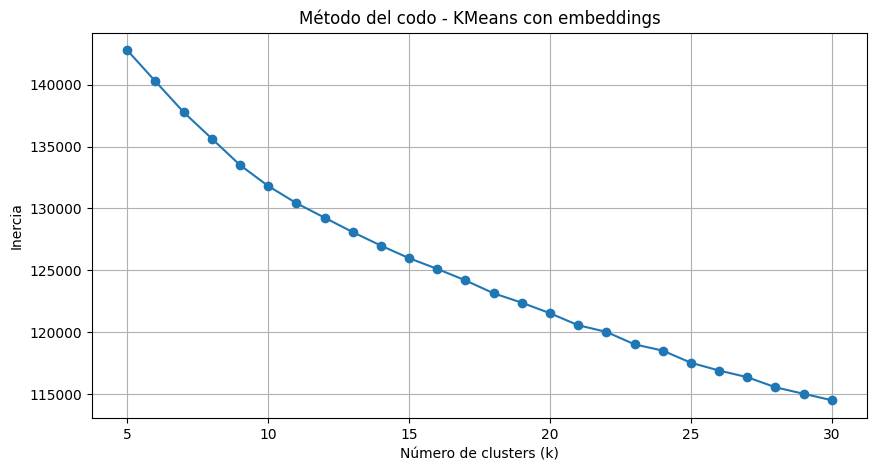

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_kmeans["k"], resultados_kmeans["inercia"], marker="o")
plt.title("Método del codo - KMeans con embeddings")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [8]:
resultados_kmeans.to_excel("resultados_kmeans.xlsx", index=False)
resultados_kmeans.to_csv("resultados_kmeans.csv", index=False)

In [9]:
best_k = 10

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df_clusters["cluster_kmeans"] = kmeans_final.fit_predict(embeddings)

print(df_clusters["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0    1507
1    2949
2    3502
3     341
4    1455
5    2641
6    1743
7    1184
8    3278
9    4918
Name: count, dtype: int64


In [10]:
for c in sorted(df_clusters["cluster_kmeans"].unique()):
    print(f"\n===== CLUSTER KMEANS {c} =====")
    
    muestra = df_clusters.loc[
        df_clusters["cluster_kmeans"] == c,
        ["resuelve", "resuelve_tokens"]
    ].head(8) 

    for _, fila in muestra.iterrows():
        print("Texto:", fila["resuelve"])
        print("Tokens:", fila["resuelve_tokens"])
        print("-" * 100)


===== CLUSTER KMEANS 0 =====
Texto: suprimir un empleo de jefe departamento de apoyo administrativo tiempo completo facultad de odontologia
Tokens: ['suprimir', 'empleo', 'apoyo', 'odontologia']
----------------------------------------------------------------------------------------------------
Texto: deja sin efectos el articulo 3 de la resolucion rectoral 19803 del 21 de octubre de 2004 prorrroga nombramiento a carlos mario jurado londoño
Tokens: ['deja', 'sin', 'efectos', 'prorrroga', 'nombramiento', 'mario', 'jurado', 'londoño']
----------------------------------------------------------------------------------------------------
Texto: modificar fecha de renuncia a unma comision administrativa de alfredo constain franco resolucion rectoral 19158 del 24 de junio de 2004
Tokens: ['modificar', 'renuncia', 'comision', 'constain']
----------------------------------------------------------------------------------------------------
Texto: aceptar renuncia de eduardo cano gaviria como repr

In [11]:
df_clusters.to_pickle("documentos_clusterizados_kmeans.pkl")
df_clusters.to_excel("documentos_clusterizados_kmeans.xlsx", index=False)

In [3]:
df_clusters = pd.read_pickle("documentos_clusterizados_kmeans.pkl")
embeddings = np.load("embeddings_resuelve.npy")

In [4]:
print(type(embeddings))
print(embeddings.shape)

<class 'numpy.ndarray'>
(23518, 384)


In [5]:
from sklearn.decomposition import PCA

C:\Users\sebas\AppData\Local\Temp\ipykernel_15256\3033743669.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))


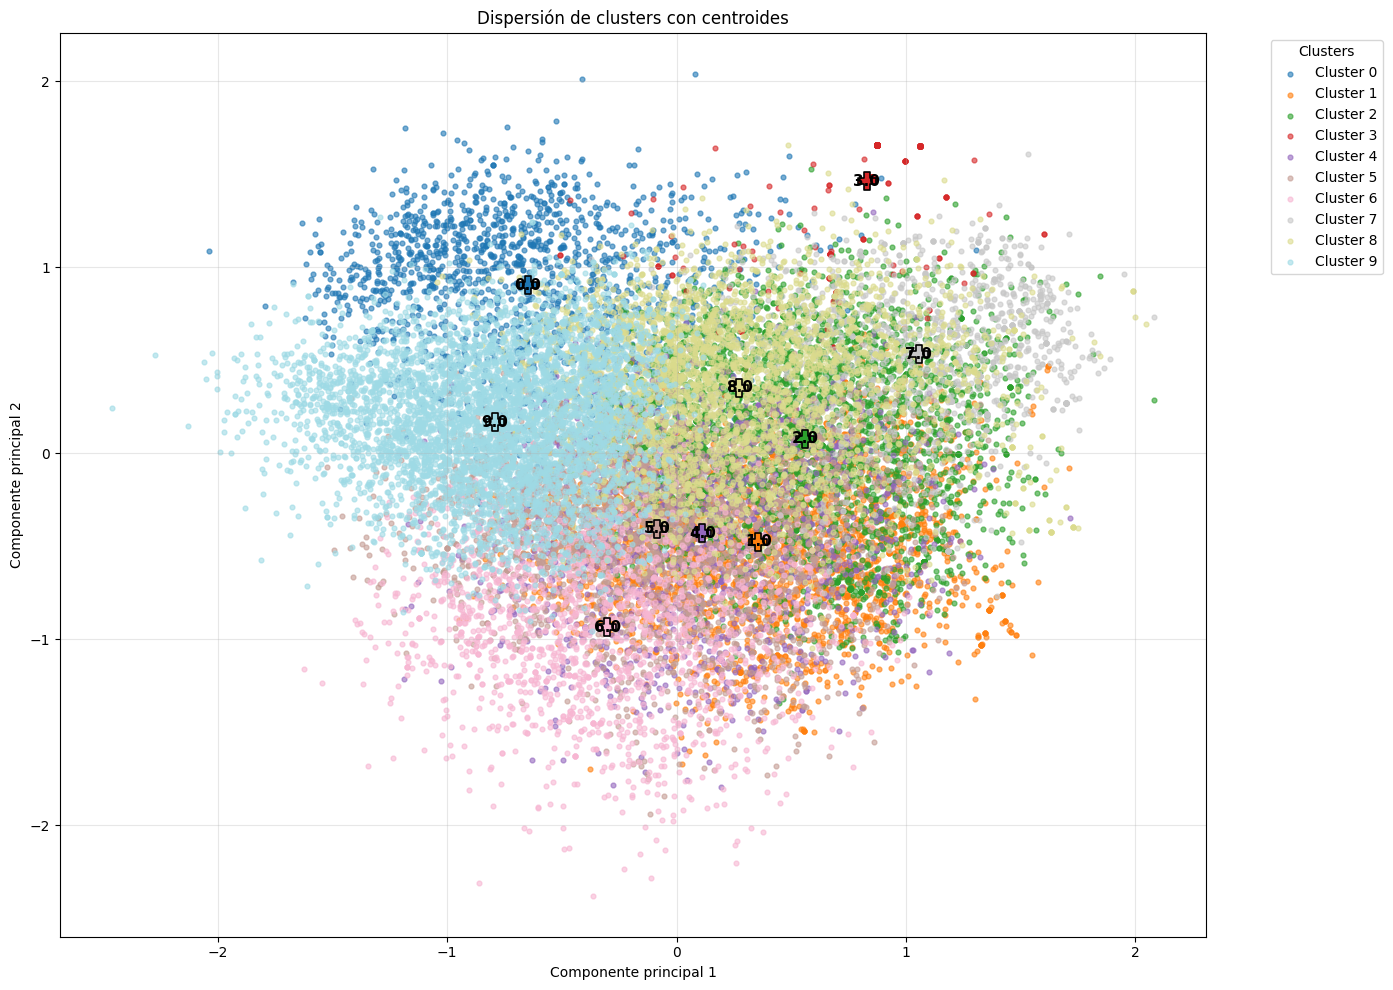

In [6]:
# Reducir embeddings a 2D para visualización
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
#Crear DataFrame para graficar
df_plot = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cluster": df_clusters["cluster_kmeans"].values
})
# Calcular centroides visuales
centroides = df_plot.groupby("cluster")[["x", "y"]].mean().reset_index()
# Graficar clusters
plt.figure(figsize=(14, 10))
# Obtener lista ordenada de clusters
clusters_ordenados = sorted(df_plot["cluster"].unique())
# Mapa de colores
cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))
# Dibujar cada cluster por separado para que la leyenda quede bien
for i, cluster_id in enumerate(clusters_ordenados):
    datos_cluster = df_plot[df_plot["cluster"] == cluster_id]
    
    plt.scatter(
        datos_cluster["x"],
        datos_cluster["y"],
        s=12,
        alpha=0.6,
        color=cmap(i),
        label=f"Cluster {cluster_id}"
    )
# Dibujar centroides
for i, row in centroides.iterrows():
    cluster_id = row["cluster"]
    color_idx = clusters_ordenados.index(cluster_id)
    
    plt.scatter(
        row["x"],
        row["y"],
        s=180,
        color=cmap(color_idx),
        marker="P",
        edgecolors="black",
        linewidths=1.2,
        zorder=5
    )
    
    plt.text(
        row["x"],
        row["y"],
        str(cluster_id),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=6
    )
# Detalles finales
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Dispersión de clusters con centroides")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

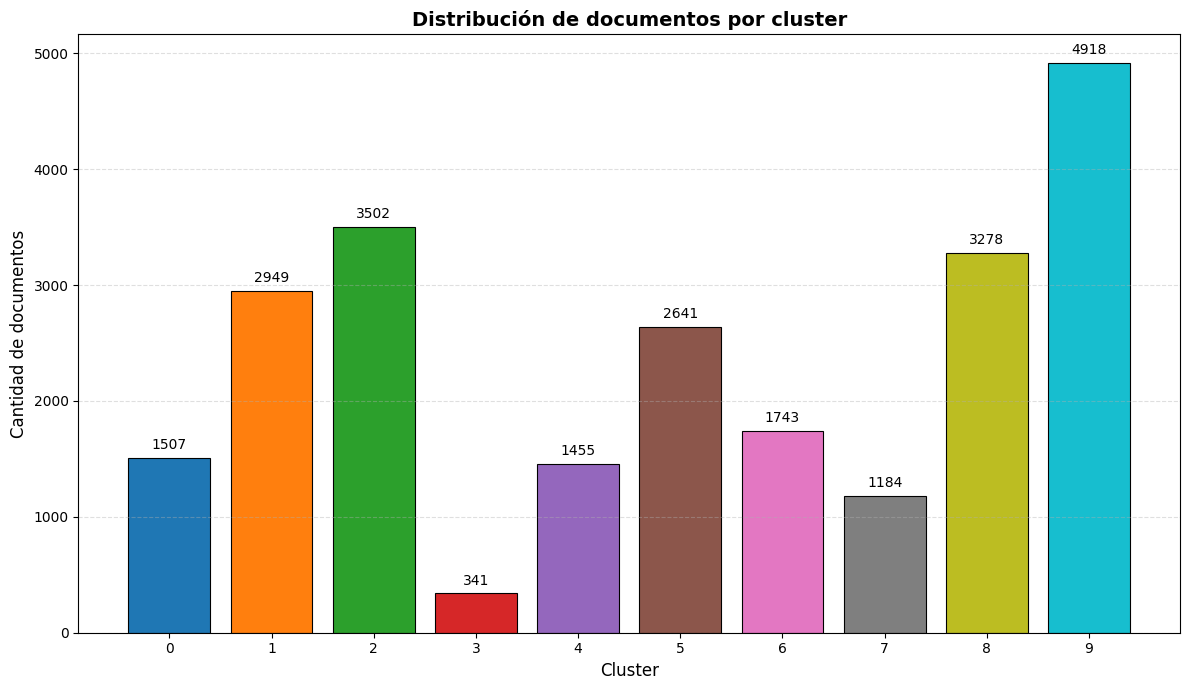

In [16]:
# Conteo de documentos por cluster

conteo_clusters = df_clusters["cluster_kmeans"].value_counts().sort_index()

# Índices y valores
clusters = conteo_clusters.index.tolist()
cantidades = conteo_clusters.values

# Colores diferenciados
colores = plt.cm.tab10(np.linspace(0, 1, len(clusters)))


# Gráfico de barras

plt.figure(figsize=(12, 7))
barras = plt.bar(clusters, cantidades, color=colores, edgecolor="black", linewidth=0.8)

# Etiquetas encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + max(cantidades) * 0.01,   # pequeño desplazamiento vertical
        f"{int(altura)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Títulos y ejes
plt.title("Distribución de documentos por cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Cantidad de documentos", fontsize=12)

# Marcas del eje X
plt.xticks(clusters, fontsize=10)
plt.yticks(fontsize=10)

# Cuadrícula horizontal sutil
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

In [17]:
from wordcloud import WordCloud

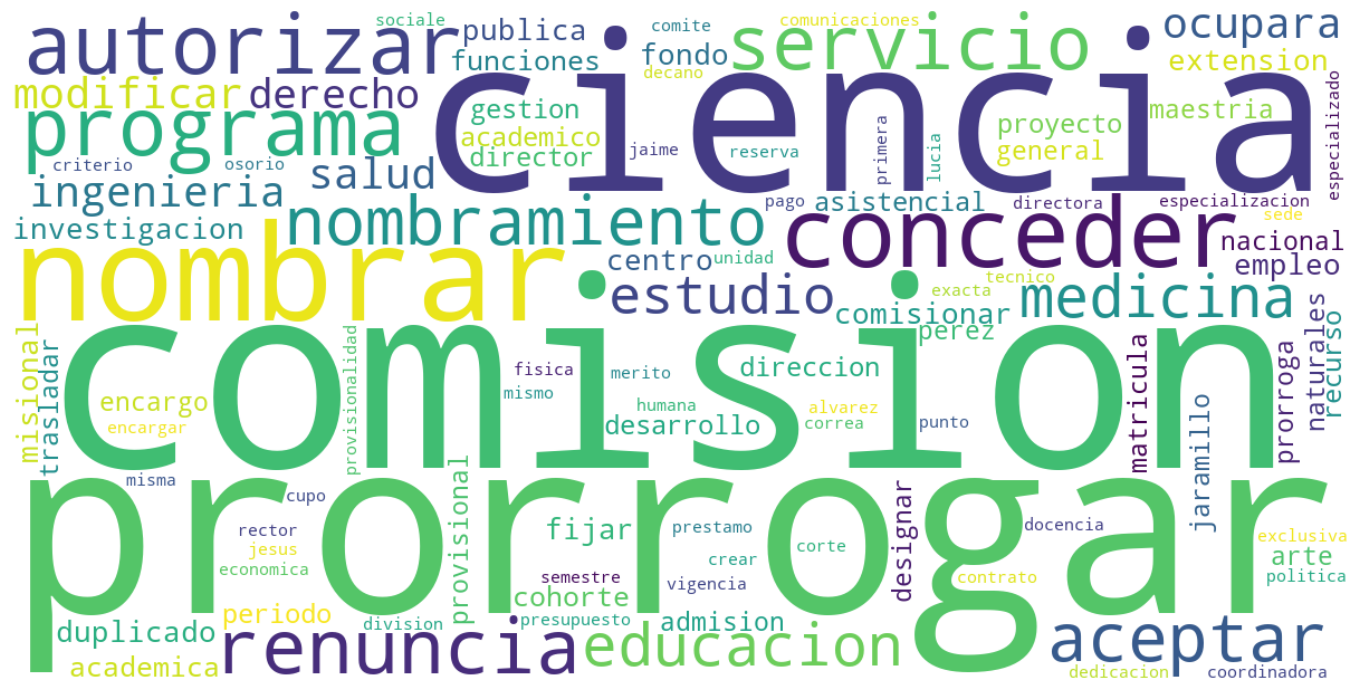

In [ ]:
# Unir todos los tokens del DataFrame en un solo texto
texto_general = " ".join(
    " ".join(tokens) for tokens in df_clusters["resuelve_tokens"] if isinstance(tokens, list)
)

# Generar nube de palabras
nube = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=100
).generate(texto_general)

# Graficar
plt.figure(figsize=(14, 7))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()